In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [248]:
from sklearn.datasets import make_blobs
df = make_blobs # generates a dataset for clustering !
df

<function sklearn.datasets._samples_generator.make_blobs(n_samples=100, n_features=2, *, centers=None, cluster_std=1.0, center_box=(-10.0, 10.0), shuffle=True, random_state=None, return_centers=False)>

In [249]:
x,y = df(n_samples=1000,centers=3,n_features=2,random_state=23)

In [250]:
x.shape

(1000, 2)

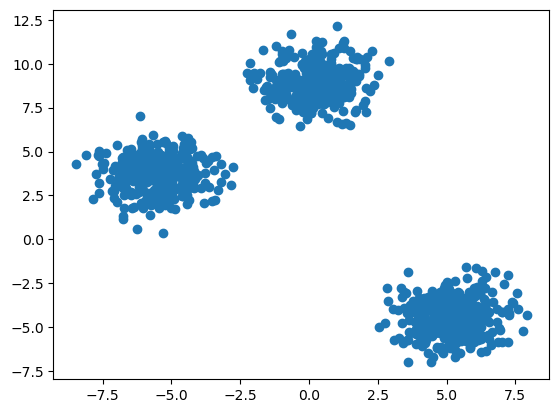

In [251]:
plt.scatter(x[:,0],x[:,1])
plt.show()

In [252]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [253]:
from sklearn.cluster import KMeans

In [254]:
# Elbow method to select the k value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

In [255]:
wcss

[38942.196941170936,
 8820.694152589953,
 1475.4321389025881,
 1272.1331875568426,
 1097.8218594795399,
 1000.0284152915319,
 855.1882481112218,
 803.8223798329767,
 709.249637464169,
 593.4127328427353]

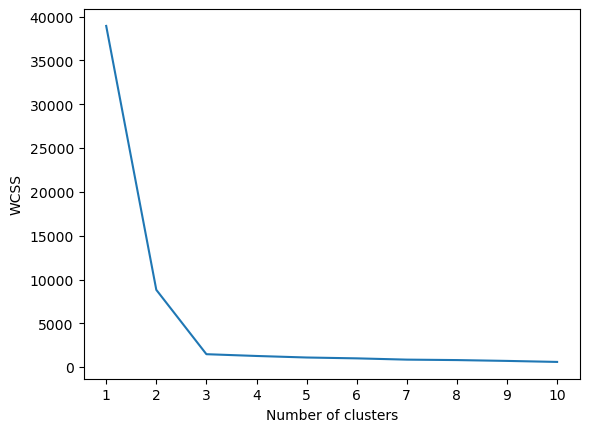

In [256]:
# plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()       

In [257]:
 kmeans=KMeans(n_clusters=3,init='k-means++')

In [258]:
y_labels = kmeans.fit_predict(x_train)

C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [259]:
y_test_labels=kmeans.predict(x_test)

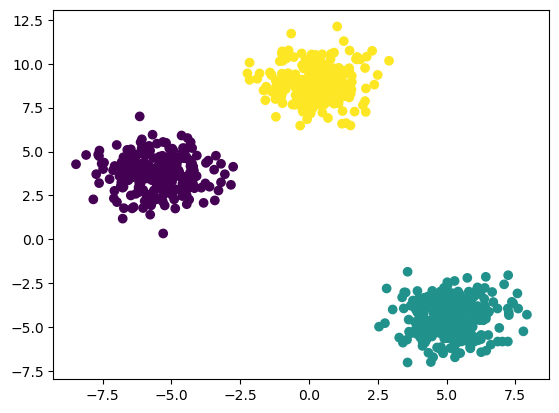

In [260]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_labels)
plt.show()

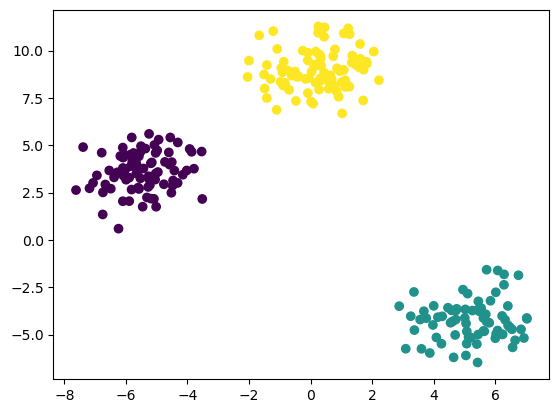

In [261]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test_labels)
plt.show()

In [262]:
# Knee Locator
!pip install kneed

In [263]:
from kneed import KneeLocator

In [264]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

3

In [265]:
#Performance Matrix
# Silhoutte score
from sklearn.metrics import silhouette_score

In [266]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train)
    score=silhouette_score(x_train,kmeans.labels_)
    silhouette_coefficients.append(score)

C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

In [268]:
silhouette_coefficients

[0.7285220879328288,
 0.8070976381014228,
 0.6408704914706645,
 0.47714653562826015,
 0.4825487946649414,
 0.3173728656300656,
 0.33769589899615565,
 0.5139115981179715,
 0.3333882904874293]

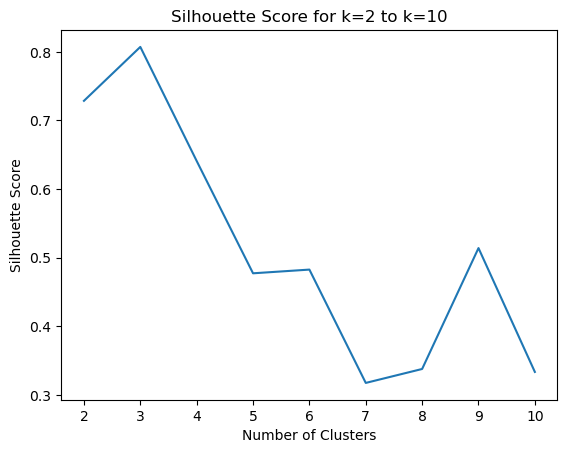

In [269]:
# plotting silhouette score 
plt.plot(range(2, 11), silhouette_coefficients)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for k=2 to k=10")
plt.show()
